Используемое устройство: cuda
Размер датасета: (4320, 2)
Диапазон: с 2025-01-01 по 2025-06-29
Пропуски по колонкам:
 date      0
target    0
dtype: int64

Размеры выборок:
Train: 3024 строк
Validation: 648 строк
Test: 648 строк


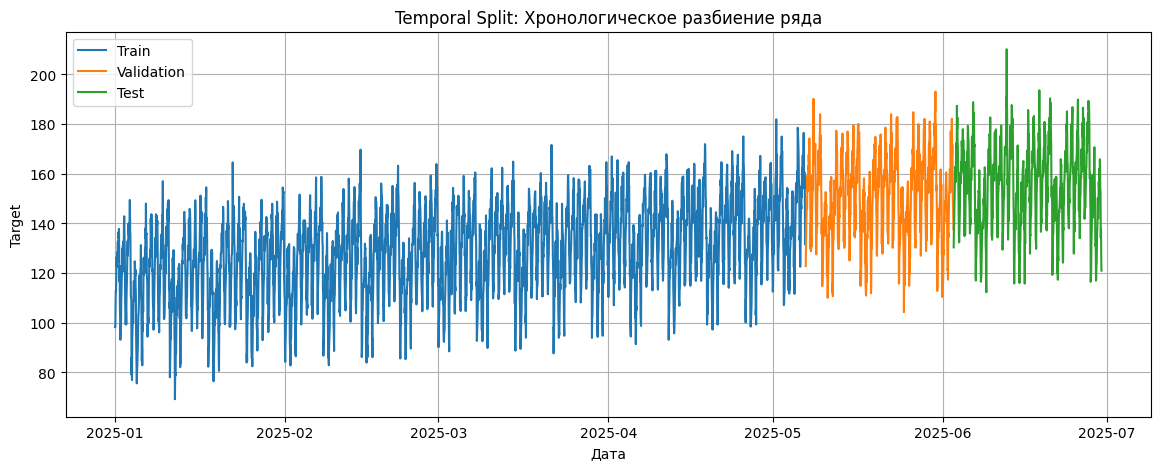

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
import os


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")


DATA_PATH = Path("S12-hw-dataset.csv")
df = pd.read_csv(DATA_PATH)


df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Sanity-check
print(f"Размер датасета: {df.shape}")
print(f"Диапазон: с {df['date'].min().date()} по {df['date'].max().date()}")
print("Пропуски по колонкам:\n", df.isna().sum())

# 4. Temporal Split (Хронологическое разбиение: 70% Train, 15% Val, 15% Test)
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"\nРазмеры выборок:")
print(f"Train: {len(train_df)} строк")
print(f"Validation: {len(val_df)} строк")
print(f"Test: {len(test_df)} строк")

# 5. Визуализация и сохранение артефакта
os.makedirs('artifacts/figures', exist_ok=True)

plt.figure(figsize=(14, 5))
plt.plot(train_df['date'], train_df['target'], label='Train')
plt.plot(val_df['date'], val_df['target'], label='Validation')
plt.plot(test_df['date'], test_df['target'], label='Test')
plt.title('Temporal Split: Хронологическое разбиение ряда')
plt.xlabel('Дата')
plt.ylabel('Target')
plt.legend()
plt.grid(True)


plt.savefig('artifacts/figures/series_split.png', bbox_inches='tight') 
plt.show()

In [2]:
from sklearn.preprocessing import StandardScaler


df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Лаговые признаки
df['lag_1'] = df['target'].shift(1)
df['lag_7'] = df['target'].shift(7)
df['lag_14'] = df['target'].shift(14)

# Скользящие окна 
df['rolling_mean_7'] = df['target'].shift(1).rolling(window=7).mean()
df['rolling_std_7'] = df['target'].shift(1).rolling(window=7).std()

# Удаляем строки с пропусками (первые 14 строк уйдут из-за lag_14)
df_features = df.dropna().reset_index(drop=True)

# 2. Повторный Temporal Split с учетом новых данных
n = len(df_features)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df_features.iloc[:train_end].copy()
val_df = df_features.iloc[train_end:val_end].copy()
test_df = df_features.iloc[val_end:].copy()

# 3. Изоляция и масштабирование
feature_cols = ['day_of_week', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7']

X_train = train_df[feature_cols]
y_train = train_df['target']

X_val = val_df[feature_cols]
y_val = val_df['target']

X_test = test_df[feature_cols]
y_test = test_df['target']


scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)


X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=feature_cols, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

print(f"Размер X_train: {X_train_scaled.shape}")
print(f"Размер X_val: {X_val_scaled.shape}")
print(f"Размер X_test: {X_test_scaled.shape}")

Размер X_train: (3014, 7)
Размер X_val: (646, 7)
Размер X_test: (646, 7)


In [3]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os

# Функция для подсчета метрик
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # Избегаем деления на ноль для MAPE, добавляя небольшое число (1e-8)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100
    return round(mae, 4), round(rmse, 4), round(mape, 4)

results = []

# Эксперимент B1: naive-last
b1_preds_val = val_df['lag_1']
b1_mae, b1_rmse, b1_mape = calculate_metrics(y_val, b1_preds_val)

results.append({
    'experiment_id': 'B1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset.csv', 'seed': 42,
    'split_summary': '70/15/15', 'window_size': 1, 'horizon': 1, 'model_summary': 'naive-last',
    'features_summary': 'lag_1', 'scaler': 'None', 'optimizer': 'None', 'lr': 'None', 'epochs_trained': 0,
    'best_val_mae': b1_mae, 'best_val_rmse': b1_rmse, 'best_val_mape': b1_mape,
    'test_mae': '', 'test_rmse': '', 'test_mape': '', 'notes': 'Baseline 1 (Previous value)'
})

# Эксперимент B2: moving-average
b2_preds_val = val_df['rolling_mean_7']
b2_mae, b2_rmse, b2_mape = calculate_metrics(y_val, b2_preds_val)

results.append({
    'experiment_id': 'B2', 'task': 'forecasting', 'dataset': 'S12-hw-dataset.csv', 'seed': 42,
    'split_summary': '70/15/15', 'window_size': 7, 'horizon': 1, 'model_summary': 'moving-average',
    'features_summary': 'rolling_mean_7', 'scaler': 'None', 'optimizer': 'None', 'lr': 'None', 'epochs_trained': 0,
    'best_val_mae': b2_mae, 'best_val_rmse': b2_rmse, 'best_val_mape': b2_mape,
    'test_mae': '', 'test_rmse': '', 'test_mape': '', 'notes': 'Baseline 2 (MA 7 days)'
})

# Эксперимент B3: ridge-lag-features
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
b3_preds_val = ridge.predict(X_val_scaled)

b3_mae, b3_rmse, b3_mape = calculate_metrics(y_val, b3_preds_val)

results.append({
    'experiment_id': 'B3', 'task': 'forecasting', 'dataset': 'S12-hw-dataset.csv', 'seed': 42,
    'split_summary': '70/15/15', 'window_size': 14, 'horizon': 1, 'model_summary': 'Ridge Regression',
    'features_summary': 'lags+rolling+calendar', 'scaler': 'StandardScaler', 'optimizer': 'None', 'lr': 'None', 'epochs_trained': 0,
    'best_val_mae': b3_mae, 'best_val_rmse': b3_rmse, 'best_val_mape': b3_mape,
    'test_mae': '', 'test_rmse': '', 'test_mape': '', 'notes': 'Baseline 3 (Ridge on features)'
})

# Сохранение результатов
runs_df = pd.DataFrame(results)
os.makedirs('artifacts', exist_ok=True)
runs_df.to_csv('artifacts/runs.csv', index=False)

print("--- Результаты бейзлайнов на валидации ---")
print(f"B1 (Naive Last): MAE={b1_mae}, RMSE={b1_rmse}, MAPE={b1_mape}%")
print(f"B2 (Moving Avg): MAE={b2_mae}, RMSE={b2_rmse}, MAPE={b2_mape}%")
print(f"B3 (Ridge):      MAE={b3_mae}, RMSE={b3_rmse}, MAPE={b3_mape}%")
print("Файл artifacts/runs.csv успешно создан/обновлен.")

--- Результаты бейзлайнов на валидации ---
B1 (Naive Last): MAE=6.4434, RMSE=8.2035, MAPE=4.3946%
B2 (Moving Avg): MAE=12.7237, RMSE=15.2363, MAPE=8.8288%
B3 (Ridge):      MAE=7.8276, RMSE=9.326, MAPE=5.2109%
Файл artifacts/runs.csv успешно создан/обновлен.


In [4]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import json

# 1. Масштабирование таргета специально для нейросети (строго на train)
target_scaler = StandardScaler()
train_target_scaled = target_scaler.fit_transform(train_df[['target']])
val_target_scaled = target_scaler.transform(val_df[['target']])
test_target_scaled = target_scaler.transform(test_df[['target']])

# 2. Функция для создания скользящих окон
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 14  # Берем 14 последних дней для прогноза следующего
X_train_seq, y_train_seq = create_sequences(train_target_scaled, WINDOW_SIZE)
X_val_seq, y_val_seq = create_sequences(val_target_scaled, WINDOW_SIZE)
X_test_seq, y_test_seq = create_sequences(test_target_scaled, WINDOW_SIZE)

# 3. PyTorch Dataset и DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64
train_loader = DataLoader(TimeSeriesDataset(X_train_seq, y_train_seq), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TimeSeriesDataset(X_val_seq, y_val_seq), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TimeSeriesDataset(X_test_seq, y_test_seq), batch_size=BATCH_SIZE, shuffle=False)

# 4. Архитектура GRU
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])  # Берем выход только с последнего шага
        return out

model = GRUModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 5. Цикл обучения
EPOCHS = 50
best_val_loss = float('inf')
train_losses, val_losses = [], []

print("Начинаем обучение GRU...")
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    # Сохраняем лучшую модель
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'artifacts/best_gru.pt')
        
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# 6. Оценка лучшей модели на Validation
model.load_state_dict(torch.load('artifacts/best_gru.pt', weights_only=True))
model.eval()
val_preds = []
with torch.no_grad():
    for X_batch, _ in val_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        val_preds.append(preds)
val_preds = np.vstack(val_preds)

# Возвращаем предсказания в исходный масштаб
val_preds_unscaled = target_scaler.inverse_transform(val_preds).flatten()

# Вырезаем реальные значения
y_val_real = val_df['target'].values[WINDOW_SIZE:]

r1_mae, r1_rmse, r1_mape = calculate_metrics(y_val_real, val_preds_unscaled)
print(f"\n--- Результаты R1 (GRU) на валидации ---")
print(f"MAE={r1_mae}, RMSE={r1_rmse}, MAPE={r1_mape}%")

# 7. Сохранение артефактов
config = {
    'architecture': 'GRU', 'input_size': 1, 'hidden_size': 64, 'num_layers': 1,
    'window_size': WINDOW_SIZE, 'batch_size': BATCH_SIZE, 'learning_rate': 1e-3,
    'epochs': EPOCHS, 'seed': 42, 'scaler': 'StandardScaler'
}
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f)

runs_df = pd.read_csv('artifacts/runs.csv')
r1_row = {
    'experiment_id': 'R1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset.csv', 'seed': 42,
    'split_summary': '70/15/15', 'window_size': WINDOW_SIZE, 'horizon': 1, 'model_summary': 'GRU univariate',
    'features_summary': 'target_only', 'scaler': 'StandardScaler', 'optimizer': 'Adam', 'lr': 1e-3, 'epochs_trained': EPOCHS,
    'best_val_mae': r1_mae, 'best_val_rmse': r1_rmse, 'best_val_mape': r1_mape,
    'test_mae': '', 'test_rmse': '', 'test_mape': '', 'notes': 'GRU on window seq'
}
runs_df = pd.concat([runs_df, pd.DataFrame([r1_row])], ignore_index=True)
runs_df.to_csv('artifacts/runs.csv', index=False)

Начинаем обучение GRU...
Epoch 10/50 | Train Loss: 0.1359 | Val Loss: 0.1953
Epoch 20/50 | Train Loss: 0.1153 | Val Loss: 0.1951
Epoch 30/50 | Train Loss: 0.1107 | Val Loss: 0.1845
Epoch 40/50 | Train Loss: 0.1086 | Val Loss: 0.1740
Epoch 50/50 | Train Loss: 0.1071 | Val Loss: 0.1757

--- Результаты R1 (GRU) на валидации ---
MAE=5.5951, RMSE=7.1789, MAPE=3.7908%


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("Вскрываем тестовую выборку...")

# 1. Финальная оценка лучшей модели (GRU) на Test
model.load_state_dict(torch.load('artifacts/best_gru.pt', weights_only=True))
model.eval()
test_preds = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        test_preds.append(preds)
test_preds = np.vstack(test_preds)

# Возвращаем масштаб
test_preds_unscaled = target_scaler.inverse_transform(test_preds).flatten()

# Вырезаем реальные значения Test с учетом окна
y_test_real = test_df['target'].values[WINDOW_SIZE:]

# Считаем метрики
test_mae, test_rmse, test_mape = calculate_metrics(y_test_real, test_preds_unscaled)
print(f"Финальный Test -> MAE: {test_mae}, RMSE: {test_rmse}, MAPE: {test_mape}%")

# 2. Жесткая фиксация результатов в runs.csv
runs_df = pd.read_csv('artifacts/runs.csv')
runs_df.loc[runs_df['experiment_id'] == 'R1', ['test_mae', 'test_rmse', 'test_mape']] = [test_mae, test_rmse, test_mape]
runs_df.to_csv('artifacts/runs.csv', index=False)

# 3. Генерация визуальных артефактов

# 3.1. Сравнение бейзлайнов (baselines_compare.png)
plt.figure(figsize=(8, 5))
models = runs_df['experiment_id'].tolist()
val_maes = runs_df['best_val_mae'].tolist()
plt.bar(models, val_maes, color=['gray', 'gray', 'gray', 'darkred'])
plt.title('Сравнение подходов по Validation MAE')
plt.ylabel('MAE')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('artifacts/figures/baselines_compare.png', bbox_inches='tight')
plt.close()

# 3.2. Кривые обучения GRU (gru_learning_curves.png)
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', color='orange')
plt.title('Кривые обучения GRU (MSE)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/gru_learning_curves.png', bbox_inches='tight')
plt.close()

# 3.3. График прогноза на Test (best_forecast_test.png)
plt.figure(figsize=(14, 5))
test_dates = test_df['date'].values[WINDOW_SIZE:]
plt.plot(test_dates, y_test_real, label='Факт (Test)', color='black', linewidth=1.5)
plt.plot(test_dates, test_preds_unscaled, label='Прогноз GRU', color='red', alpha=0.8, linewidth=1.5)
plt.title('Финальный контроль: Прогноз GRU на тестовых данных')
plt.xlabel('Дата')
plt.ylabel('Target')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/best_forecast_test.png', bbox_inches='tight')
plt.close()

print("Артефакты успешно сгенерированы.")

Вскрываем тестовую выборку...
Финальный Test -> MAE: 6.3494, RMSE: 7.9941, MAPE: 4.1363%
Артефакты успешно сгенерированы.
